# Notebook 01: Data Cleaning & Quality Report — HealthFirst Australia

**Project:** HealthFirst Australia — Revenue Intelligence Platform  
**Purpose:** Audit all five raw datasets for quality issues, apply business-rule fixes, and export clean datasets ready for KPI analysis.  
**Author:** Analytics Team  
**Date:** 2026-04-12

---

### Issues to Fix

| # | Dataset | Issue | Fix |
|---|---------|-------|-----|
| 1 | appointments | NULL `patient_gap` | Fill with 0 (bulk_bill = no patient out-of-pocket cost) |
| 2 | appointments | ~60 duplicate rows | Drop duplicates, keep first |
| 3 | appointments | Inconsistent `specialty` names (`'MH'`, `'mental health'`, `'Mental_Health'`) | Standardise to canonical list |
| 4 | satisfaction_surveys | NULL `overall_score` (~4%) | Fill with column median |
| 5 | satisfaction_surveys | `survey_date` before `appointment_date` | Set to `appointment_date + 1 day` |
| 6 | patients | Invalid Medicare number format (contains `'INVALID-'`) | Add `invalid_medicare_flag` column |
| 7 | appointments | `appointment_date` stored as string | Parse as `datetime64` |

In [1]:
# ── Imports & global display settings ─────────────────────────────────────────
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid')

# ── Directory constants ────────────────────────────────────────────────────────
RAW_DIR     = '../data/raw/'
CLEAN_DIR   = '../data/cleaned/'
REPORTS_DIR = '../reports/'

for d in [CLEAN_DIR, REPORTS_DIR]:
    os.makedirs(d, exist_ok=True)

print('Environment ready.')
print(f'  RAW     : {os.path.abspath(RAW_DIR)}')
print(f'  CLEANED : {os.path.abspath(CLEAN_DIR)}')
print(f'  REPORTS : {os.path.abspath(REPORTS_DIR)}')

Environment ready.
  RAW     : /Users/sahana/Documents/revenue-intelligence/data/raw
  CLEANED : /Users/sahana/Documents/revenue-intelligence/data/cleaned
  REPORTS : /Users/sahana/Documents/revenue-intelligence/reports


---
## 1. Load Raw Data

In [2]:
# ── Load all five raw CSV files ────────────────────────────────────────────────
patients     = pd.read_csv(RAW_DIR + 'patients.csv')
appointments = pd.read_csv(RAW_DIR + 'appointments.csv')
staff        = pd.read_csv(RAW_DIR + 'staff.csv')
surveys      = pd.read_csv(RAW_DIR + 'satisfaction_surveys.csv')
billing      = pd.read_csv(RAW_DIR + 'billing_claims.csv')

raw_datasets = {
    'patients'    : patients,
    'appointments': appointments,
    'staff'       : staff,
    'surveys'     : surveys,
    'billing'     : billing,
}

print('Raw file shapes:')
for name, df in raw_datasets.items():
    print(f'  {name:>15s}  →  {df.shape[0]:>7,} rows  ×  {df.shape[1]:>2} cols')

Raw file shapes:
         patients  →    3,000 rows  ×  19 cols
     appointments  →   20,060 rows  ×  16 cols
            staff  →       80 rows  ×  11 cols
          surveys  →    3,894 rows  ×  12 cols
          billing  →   11,094 rows  ×  10 cols


In [3]:
# ── Preview appointments (the most complex table) ──────────────────────────────
print('appointments.dtypes:')
print(appointments.dtypes)
print()
appointments.head(3)

appointments.dtypes:
appointment_id        int64
patient_id            int64
staff_id              int64
clinic_id             int64
appointment_date     object
specialty            object
appointment_type     object
wait_days             int64
status               object
billing_type         object
scheduled_fee       float64
billed_amount       float64
medicare_rebate     float64
patient_gap         float64
insurance_paid      float64
staff_cost          float64
dtype: object



,appointment_id,patient_id,staff_id,clinic_id,appointment_date,specialty,appointment_type,wait_days,status,billing_type,scheduled_fee,billed_amount,medicare_rebate,patient_gap,insurance_paid,staff_cost
0,1,1003,11,6,2025-01-29,GP,in_person,15,completed,private,42.85,94.27,0.00,0.00,86.74,17.36
1,2,492,20,8,2025-02-19,GP,in_person,13,completed,gap_payment,42.85,94.27,42.85,51.42,25.43,17.66
2,3,89,42,8,2025-08-16,Cardiology,in_person,27,completed,private,155.00,434.00,0.00,0.00,350.33,69.74


---
## 2. Data Quality Audit (Before Cleaning)

In [4]:
# ── Helper: NULL counts per dataset ───────────────────────────────────────────
def null_summary(df, name):
    s = df.isnull().sum()
    s = s[s > 0].rename('null_count').to_frame()
    s['null_pct'] = (s['null_count'] / len(df) * 100).round(2)
    s.index = pd.MultiIndex.from_product([[name], s.index],
                                         names=['dataset', 'column'])
    return s

audit_before = pd.concat([
    null_summary(df, name) for name, df in raw_datasets.items()
])

print('=== NULL COUNTS BEFORE CLEANING ===')
print(audit_before.to_string())

=== NULL COUNTS BEFORE CLEANING ===
                                 null_count  null_pct
dataset      column                                  
patients     health_fund               1817     60.57
             chronic_conditions        1404     46.80
appointments patient_gap                326      1.63
surveys      overall_score              143      3.67
             complaint_category        2677     68.75
billing      rejection_reason          9995     90.09


In [5]:
# ── Audit: Duplicate appointment rows ─────────────────────────────────────────
dup_count_before = appointments.duplicated().sum()
print(f'Full duplicate rows in appointments (before): {dup_count_before:,}')

# ── Audit: Specialty name inconsistencies ─────────────────────────────────────
print('\nRaw specialty value counts in appointments:')
print(appointments['specialty'].value_counts().to_string())

# ── Audit: appointment_date dtype ─────────────────────────────────────────────
print(f'\nappointments["appointment_date"] dtype: {appointments["appointment_date"].dtype}')

# ── Audit: Invalid Medicare numbers ───────────────────────────────────────────
invalid_medicare_mask_raw = patients['medicare_number'].astype(str).str.contains('INVALID-', na=False)
print(f'\nPatients with invalid Medicare numbers: {invalid_medicare_mask_raw.sum():,}')

Full duplicate rows in appointments (before): 60

Raw specialty value counts in appointments:
specialty
GP               8110
Dermatology      2392
Mental Health    2089
Emergency        1985
Paediatrics      1589
Cardiology       1582
Orthopaedics     1200
Oncology          859
Mental_Health      92
mental health      85
MH                 77

appointments["appointment_date"] dtype: object

Patients with invalid Medicare numbers: 56


In [6]:
# ── Audit: Survey date before appointment date (requires a join) ───────────────
# Parse dates temporarily just for the audit
appt_dates_raw  = appointments[['appointment_id', 'appointment_date']].copy()
appt_dates_raw['appointment_date'] = pd.to_datetime(
    appt_dates_raw['appointment_date'], errors='coerce'
)

surveys_audit = surveys.copy()
surveys_audit['survey_date'] = pd.to_datetime(surveys_audit['survey_date'], errors='coerce')
surveys_audit = surveys_audit.merge(appt_dates_raw, on='appointment_id', how='left')

bad_survey_dates_before = int(
    (surveys_audit['survey_date'] < surveys_audit['appointment_date']).sum()
)
print(f'Survey rows where survey_date < appointment_date: {bad_survey_dates_before:,}')

# ── Audit: NULL overall_score ─────────────────────────────────────────────────
null_score_before = int(surveys['overall_score'].isna().sum())
print(f'NULL overall_score in surveys: {null_score_before:,}  '
      f'({null_score_before / len(surveys) * 100:.1f}%)')

Survey rows where survey_date < appointment_date: 52
NULL overall_score in surveys: 143  (3.7%)


---
## 3. Apply All Fixes

In [7]:
# ════════════════════════════════════════════════════════════════════════════
# FIX 7 — Parse appointment_date as datetime64
# Business reason: Time-series grouping (monthly trends, wait-day calculations)
# requires a proper datetime type, not a plain string.
# ════════════════════════════════════════════════════════════════════════════
appt_clean = appointments.copy()

appt_clean['appointment_date'] = pd.to_datetime(
    appt_clean['appointment_date'], errors='coerce'
)

print(f'appointment_date dtype  after fix : {appt_clean["appointment_date"].dtype}')
print(f'Unparseable dates (coerced to NaT): {appt_clean["appointment_date"].isna().sum():,}')

appointment_date dtype  after fix : datetime64[ns]
Unparseable dates (coerced to NaT): 0


In [8]:
# ════════════════════════════════════════════════════════════════════════════
# FIX 2 — Drop duplicate appointment rows (keep first occurrence)
# Business reason: Duplicate rows double-count revenue, inflate appointment
# volumes, and skew wait-time and no-show rate calculations.
# ════════════════════════════════════════════════════════════════════════════
rows_before_dedup = len(appt_clean)
appt_clean = appt_clean.drop_duplicates(keep='first').reset_index(drop=True)
rows_after_dedup  = len(appt_clean)

print(f'Rows before deduplication : {rows_before_dedup:,}')
print(f'Rows after  deduplication : {rows_after_dedup:,}')
print(f'Duplicate rows removed    : {rows_before_dedup - rows_after_dedup:,}')

Rows before deduplication : 20,060
Rows after  deduplication : 20,000
Duplicate rows removed    : 60


In [9]:
# ════════════════════════════════════════════════════════════════════════════
# FIX 3 — Standardise inconsistent specialty names
# Business reason: 'MH', 'mental health', 'Mental_Health' are the same service
# line. Without standardisation, specialty-level aggregations (revenue by
# specialty, wait times, satisfaction) will be incorrectly fragmented.
# ════════════════════════════════════════════════════════════════════════════
SPECIALTY_MAP = {
    # Mental Health variants
    'mh'           : 'Mental Health',
    'mental health': 'Mental Health',
    'mental_health': 'Mental Health',
    # Standard names (title-case normalisation)
    'gp'                : 'GP',
    'general practice'  : 'GP',
    'cardiology'        : 'Cardiology',
    'oncology'          : 'Oncology',
    'orthopaedics'      : 'Orthopaedics',
    'orthopaedic'       : 'Orthopaedics',
    'ortho'             : 'Orthopaedics',
    'paediatrics'       : 'Paediatrics',
    'paediatric'        : 'Paediatrics',
    'paeds'             : 'Paediatrics',
    'emergency'         : 'Emergency',
    'dermatology'       : 'Dermatology',
    'derm'              : 'Dermatology',
}

raw_specialty_counts = appt_clean['specialty'].value_counts().copy()

appt_clean['specialty'] = (
    appt_clean['specialty']
    .str.strip()
    .str.lower()
    .map(lambda x: SPECIALTY_MAP.get(x, x.title()) if isinstance(x, str) else x)
)

print('Specialty values AFTER standardisation:')
print(appt_clean['specialty'].value_counts().to_string())

Specialty values AFTER standardisation:
specialty
GP               8089
Dermatology      2383
Mental Health    2335
Emergency        1984
Paediatrics      1585
Cardiology       1573
Orthopaedics     1195
Oncology          856


In [10]:
# ════════════════════════════════════════════════════════════════════════════
# FIX 1 — Fill NULL patient_gap with 0
# Business reason: For bulk_bill appointments, Medicare covers 100% and the
# patient pays nothing (no gap payment). A NULL here is a data-entry omission,
# not truly missing data. Leaving it NULL would exclude these rows from
# gap-payment calculations and understate bulk-billing prevalence.
# ════════════════════════════════════════════════════════════════════════════
null_gap_before = int(appt_clean['patient_gap'].isna().sum())
appt_clean['patient_gap'] = appt_clean['patient_gap'].fillna(0)
null_gap_after  = int(appt_clean['patient_gap'].isna().sum())

print(f'NULL patient_gap  before fix : {null_gap_before:,}')
print(f'NULL patient_gap  after  fix : {null_gap_after:,}')

NULL patient_gap  before fix : 326
NULL patient_gap  after  fix : 0


In [11]:
# ════════════════════════════════════════════════════════════════════════════
# FIX 6 — Flag invalid Medicare number format in patients
# Business reason: Rows containing 'INVALID-' cannot be used for Medicare
# claim submissions. Rather than dropping these patients (which would hide
# the problem), we flag them for downstream remediation.
# A value of 1 = invalid; 0 = OK.
# ════════════════════════════════════════════════════════════════════════════
patients_clean = patients.copy()

patients_clean['invalid_medicare_flag'] = (
    patients_clean['medicare_number']
    .astype(str)
    .str.contains('INVALID-', case=True, na=False)
    .astype(int)
)

n_invalid = int(patients_clean['invalid_medicare_flag'].sum())
print(f'Patients flagged with invalid Medicare number: {n_invalid:,}')
print(f'  ({n_invalid / len(patients_clean) * 100:.1f}% of patient records)')
print()
print('Sample invalid records:')
print(
    patients_clean.loc[
        patients_clean['invalid_medicare_flag'] == 1,
        ['patient_id', 'full_name', 'medicare_number', 'invalid_medicare_flag']
    ].head(5).to_string(index=False)
)

Patients flagged with invalid Medicare number: 56
  (1.9% of patient records)

Sample invalid records:
 patient_id      full_name medicare_number  invalid_medicare_flag
        137  Hannah Taylor     INVALID-978                      1
        162  Lucas Johnson     INVALID-728                      1
        211    Isla Wilson     INVALID-577                      1
        396     Isla Evans     INVALID-616                      1
        408 Isabella Smith     INVALID-219                      1


In [12]:
# ════════════════════════════════════════════════════════════════════════════
# FIX 4 — Fill NULL overall_score in satisfaction_surveys with the median
# Business reason: ~4% of respondents skipped the overall score question.
# Dropping them would shrink the sample and introduce non-response bias.
# Median imputation preserves the score distribution without distorting the
# mean, and is robust to the 1–10 bounded scale used in the survey.
# ════════════════════════════════════════════════════════════════════════════
surveys_clean = surveys.copy()

score_median     = surveys_clean['overall_score'].median()
null_score_after = 0  # will be confirmed below

surveys_clean['overall_score'] = surveys_clean['overall_score'].fillna(score_median)
null_score_after = int(surveys_clean['overall_score'].isna().sum())

print(f'Median overall_score used for imputation : {score_median:.2f}')
print(f'NULL overall_score  before fix           : {null_score_before:,}')
print(f'NULL overall_score  after  fix           : {null_score_after:,}')

Median overall_score used for imputation : 7.00
NULL overall_score  before fix           : 143
NULL overall_score  after  fix           : 0


In [13]:
# ════════════════════════════════════════════════════════════════════════════
# FIX 5 — Correct survey_date values that precede their appointment_date
# Business reason: A patient cannot complete a post-visit satisfaction survey
# before the appointment has taken place. These are corrupted timestamps,
# likely due to a date-entry bug in the survey platform. We set the survey
# date to appointment_date + 1 day as a safe, conservative estimate.
# ════════════════════════════════════════════════════════════════════════════
surveys_clean['survey_date'] = pd.to_datetime(
    surveys_clean['survey_date'], errors='coerce'
)

# Pull cleaned appointment dates for the join (deduped, datetime-parsed)
appt_dates_for_join = (
    appt_clean[['appointment_id', 'appointment_date']]
    .drop_duplicates(subset='appointment_id')
)

surveys_clean = surveys_clean.merge(
    appt_dates_for_join, on='appointment_id', how='left'
)

bad_date_mask = surveys_clean['survey_date'] < surveys_clean['appointment_date']
bad_count_before_fix = int(bad_date_mask.sum())

surveys_clean.loc[bad_date_mask, 'survey_date'] = (
    surveys_clean.loc[bad_date_mask, 'appointment_date'] + pd.Timedelta(days=1)
)

bad_count_after_fix = int(
    (surveys_clean['survey_date'] < surveys_clean['appointment_date']).sum()
)

# Remove the helper column; appointment_date lives in appt_clean
surveys_clean = surveys_clean.drop(columns=['appointment_date'])

print(f'Rows with survey_date < appointment_date  before fix: {bad_count_before_fix:,}')
print(f'Rows with survey_date < appointment_date  after  fix: {bad_count_after_fix:,}')

Rows with survey_date < appointment_date  before fix: 52
Rows with survey_date < appointment_date  after  fix: 0


---
## 4. Before / After Quality Summary

In [14]:
# ── Collect cleaned datasets ───────────────────────────────────────────────────
clean_datasets = {
    'patients'    : patients_clean,
    'appointments': appt_clean,
    'staff'       : staff.copy(),
    'surveys'     : surveys_clean,
    'billing'     : billing.copy(),
}

# ── Shape comparison ──────────────────────────────────────────────────────────
shape_df = pd.DataFrame({
    'dataset'     : list(raw_datasets.keys()),
    'rows_raw'    : [df.shape[0] for df in raw_datasets.values()],
    'rows_clean'  : [df.shape[0] for df in clean_datasets.values()],
    'cols_raw'    : [df.shape[1] for df in raw_datasets.values()],
    'cols_clean'  : [df.shape[1] for df in clean_datasets.values()],
})
shape_df['rows_removed'] = shape_df['rows_raw'] - shape_df['rows_clean']
shape_df['cols_added']   = shape_df['cols_clean'] - shape_df['cols_raw']

print('=== SHAPE COMPARISON: RAW vs CLEANED ===')
print(shape_df.to_string(index=False))

=== SHAPE COMPARISON: RAW vs CLEANED ===
     dataset  rows_raw  rows_clean  cols_raw  cols_clean  rows_removed  cols_added
    patients      3000        3000        19          20             0           1
appointments     20060       20000        16          16            60           0
       staff        80          80        11          11             0           0
     surveys      3894        3894        12          12             0           0
     billing     11094       11094        10          10             0           0


In [15]:
# ── Remaining NULLs after cleaning ───────────────────────────────────────────
audit_after = pd.concat([
    null_summary(df, name) for name, df in clean_datasets.items()
])

print('=== REMAINING NULLS AFTER CLEANING ===')
if audit_after.empty:
    print('No remaining nulls in any tracked column. ✓')
else:
    print(audit_after.to_string())

=== REMAINING NULLS AFTER CLEANING ===
                             null_count  null_pct
dataset  column                                  
patients health_fund               1817     60.57
         chronic_conditions        1404     46.80
surveys  complaint_category        2677     68.75
billing  rejection_reason          9995     90.09


In [16]:
# ── Fix-by-fix summary table ──────────────────────────────────────────────────
fix_summary = pd.DataFrame([
    {
        'Fix': 1, 'Dataset': 'appointments',
        'Issue': 'NULL patient_gap',
        'Before': null_gap_before, 'After': null_gap_after,
    },
    {
        'Fix': 2, 'Dataset': 'appointments',
        'Issue': 'Duplicate rows',
        'Before': rows_before_dedup, 'After': rows_after_dedup,
    },
    {
        'Fix': 3, 'Dataset': 'appointments',
        'Issue': 'Inconsistent specialty names',
        'Before': 'variants: MH / mental health / Mental_Health',
        'After': 'all → Mental Health',
    },
    {
        'Fix': 4, 'Dataset': 'surveys',
        'Issue': 'NULL overall_score',
        'Before': null_score_before,
        'After': f'0 (imputed with median={score_median:.1f})',
    },
    {
        'Fix': 5, 'Dataset': 'surveys',
        'Issue': 'survey_date < appointment_date',
        'Before': bad_count_before_fix, 'After': bad_count_after_fix,
    },
    {
        'Fix': 6, 'Dataset': 'patients',
        'Issue': 'Invalid Medicare number format',
        'Before': n_invalid, 'After': f'{n_invalid} flagged (not dropped)',
    },
    {
        'Fix': 7, 'Dataset': 'appointments',
        'Issue': 'appointment_date stored as string',
        'Before': 'dtype=object', 'After': 'dtype=datetime64',
    },
])

print('=== DATA QUALITY FIX SUMMARY ===')
print(fix_summary.to_string(index=False))

=== DATA QUALITY FIX SUMMARY ===
 Fix      Dataset                             Issue                                       Before                       After
   1 appointments                  NULL patient_gap                                          326                           0
   2 appointments                    Duplicate rows                                        20060                       20000
   3 appointments      Inconsistent specialty names variants: MH / mental health / Mental_Health         all → Mental Health
   4      surveys                NULL overall_score                                          143 0 (imputed with median=7.0)
   5      surveys    survey_date < appointment_date                                           52                           0
   6     patients    Invalid Medicare number format                                           56    56 flagged (not dropped)
   7 appointments appointment_date stored as string                                 dtype=ob

---
## 5. Visualisation — NULL Counts Before vs After Cleaning

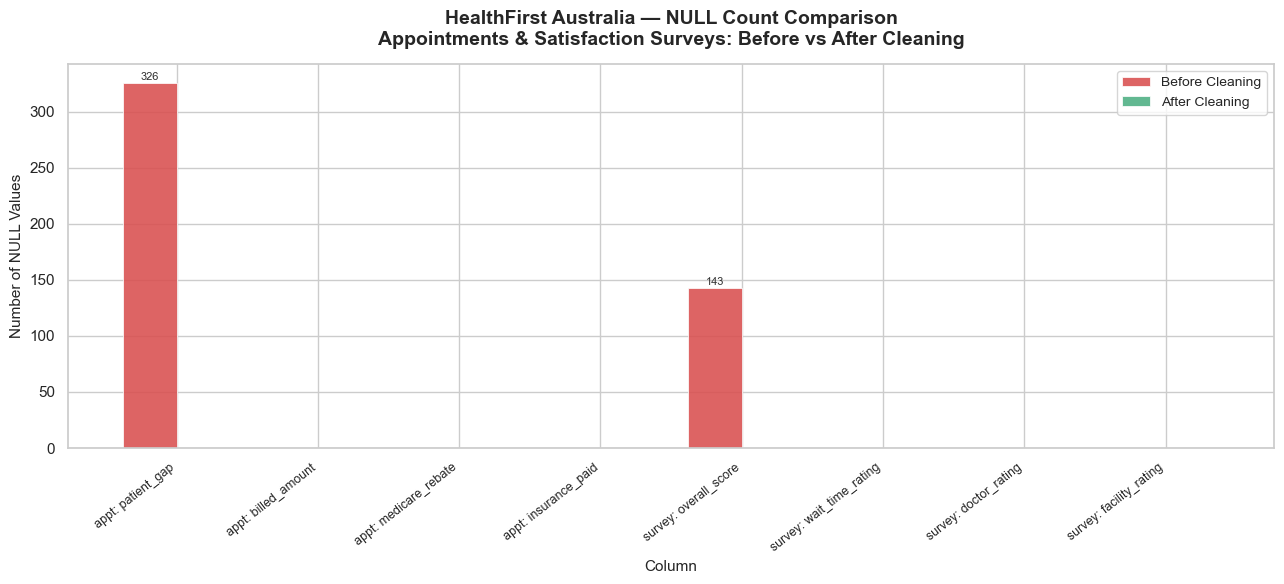

Chart saved → /Users/sahana/Documents/revenue-intelligence/reports/data_quality_report.png


In [17]:
# ── Bar chart: null counts before vs after for appointments & surveys ──────────
# Focus on the columns that had meaningful null issues in these two datasets.

appt_tracked_cols   = ['patient_gap', 'billed_amount', 'medicare_rebate', 'insurance_paid']
survey_tracked_cols = ['overall_score', 'wait_time_rating', 'doctor_rating', 'facility_rating']

before_nulls_appt   = {f'appt: {c}': int(appointments[c].isna().sum()) for c in appt_tracked_cols}
before_nulls_survey = {f'survey: {c}': int(surveys[c].isna().sum()) for c in survey_tracked_cols}
after_nulls_appt    = {f'appt: {c}': int(appt_clean[c].isna().sum()) for c in appt_tracked_cols}
after_nulls_survey  = {f'survey: {c}': int(surveys_clean[c].isna().sum()) for c in survey_tracked_cols}

compare_df = pd.DataFrame({
    'Before Cleaning': {**before_nulls_appt, **before_nulls_survey},
    'After Cleaning' : {**after_nulls_appt,  **after_nulls_survey},
})

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

x     = np.arange(len(compare_df))
width = 0.38

bars_before = ax.bar(
    x - width / 2, compare_df['Before Cleaning'], width,
    label='Before Cleaning', color='#D94F4F', alpha=0.88, edgecolor='white', linewidth=0.6
)
bars_after = ax.bar(
    x + width / 2, compare_df['After Cleaning'], width,
    label='After Cleaning', color='#4CAF82', alpha=0.88, edgecolor='white', linewidth=0.6
)

ax.set_title(
    'HealthFirst Australia — NULL Count Comparison\n'
    'Appointments & Satisfaction Surveys: Before vs After Cleaning',
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xlabel('Column', fontsize=11)
ax.set_ylabel('Number of NULL Values', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(compare_df.index, rotation=38, ha='right', fontsize=9)
ax.legend(fontsize=10)

# Annotate each 'before' bar with its count
for bar in bars_before:
    h = bar.get_height()
    if h > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2, h + 0.5,
            f'{int(h):,}', ha='center', va='bottom', fontsize=8, color='#333'
        )

plt.tight_layout()
chart_path = REPORTS_DIR + 'data_quality_report.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved → {os.path.abspath(chart_path)}')

---
## 6. Save Cleaned Files to `data/cleaned/`

In [18]:
# ── Export all five cleaned datasets to CSV ────────────────────────────────────
output_map = {
    'patients.csv'             : patients_clean,
    'appointments.csv'         : appt_clean,
    'staff.csv'                : staff.copy(),
    'satisfaction_surveys.csv' : surveys_clean,
    'billing_claims.csv'       : billing.copy(),
}

for fname, df in output_map.items():
    out_path = CLEAN_DIR + fname
    df.to_csv(out_path, index=False)
    print(
        f'Saved  {fname:35s}  '
        f'({len(df):,} rows, {df.shape[1]} cols)  →  {os.path.abspath(out_path)}'
    )

print('\nAll five cleaned files written successfully.')

Saved  patients.csv                         (3,000 rows, 20 cols)  →  /Users/sahana/Documents/revenue-intelligence/data/cleaned/patients.csv
Saved  appointments.csv                     (20,000 rows, 16 cols)  →  /Users/sahana/Documents/revenue-intelligence/data/cleaned/appointments.csv
Saved  staff.csv                            (80 rows, 11 cols)  →  /Users/sahana/Documents/revenue-intelligence/data/cleaned/staff.csv
Saved  satisfaction_surveys.csv             (3,894 rows, 12 cols)  →  /Users/sahana/Documents/revenue-intelligence/data/cleaned/satisfaction_surveys.csv
Saved  billing_claims.csv                   (11,094 rows, 10 cols)  →  /Users/sahana/Documents/revenue-intelligence/data/cleaned/billing_claims.csv

All five cleaned files written successfully.


---
## 7. Sanity Check — Reload from Disk

In [19]:
# ── Reload cleaned files from disk and verify integrity ───────────────────────
print(f'{'File':<35}  {'Rows':>7}  {'Cols':>4}  {'Total NULLs':>11}')
print('-' * 65)
for fname in output_map:
    df_reload    = pd.read_csv(CLEAN_DIR + fname)
    total_nulls  = int(df_reload.isnull().sum().sum())
    print(
        f'{fname:<35}  {len(df_reload):>7,}  {df_reload.shape[1]:>4}  '
        f'{total_nulls:>11,}'
    )

print()
print('Sanity check complete — proceed to Notebook 02 for KPI analysis.')

File                                    Rows  Cols  Total NULLs
-----------------------------------------------------------------
patients.csv                           3,000    20        3,221
appointments.csv                      20,000    16            0
staff.csv                                 80    11            0
satisfaction_surveys.csv               3,894    12        2,677
billing_claims.csv                    11,094    10        9,995

Sanity check complete — proceed to Notebook 02 for KPI analysis.
